In [1]:
# Cell 1: Environment and GPU check

import sys
import platform
from pathlib import Path

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    
    print("\nPyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    
    if torch.cuda.is_available():
        print("CUDA version used by PyTorch:", torch.version.cuda)
        print("GPU name:", torch.cuda.get_device_name(0))
        print("GPU memory allocated GB:", round(torch.cuda.memory_allocated(0) / 1024**3, 3))
        print("GPU memory reserved GB:", round(torch.cuda.memory_reserved(0) / 1024**3, 3))
    else:
        print("CUDA is not available in this notebook environment.")
        
except ImportError as error:
    print("PyTorch is not installed or not available in this environment.")
    print(error)

Python executable: d:\Projects\evidence_fashion_recommender\.venv\Scripts\python.exe
Python version: 3.11.15 (main, Jun  2 2026, 22:29:49) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version used by PyTorch: 12.8
GPU name: NVIDIA GeForce RTX 5070 Ti
GPU memory allocated GB: 0.0
GPU memory reserved GB: 0.0


In [2]:
# Cell 2: Project folders and notebook paths

from pathlib import Path

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
KB_DIR = DATA_DIR / "kb"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
EMBEDDINGS_DIR = OUTPUTS_DIR / "embeddings"
INDEXES_DIR = OUTPUTS_DIR / "indexes"
RESULTS_DIR = OUTPUTS_DIR / "results"
FIGURES_DIR = OUTPUTS_DIR / "figures"

folders = [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    KB_DIR,
    OUTPUTS_DIR,
    EMBEDDINGS_DIR,
    INDEXES_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("\nCreated/verified folders:")
for folder in folders:
    print("-", folder.relative_to(PROJECT_ROOT))

Project root: d:\Projects\evidence_fashion_recommender

Created/verified folders:
- data
- data\raw
- data\processed
- data\kb
- outputs
- outputs\embeddings
- outputs\indexes
- outputs\results
- outputs\figures


In [3]:
# Cell 3: Core library imports

import os
import json
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from datasets import load_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Core imports loaded successfully.")
print("Ready for Stage 0: real dataset loading and inspection.")

Core imports loaded successfully.
Ready for Stage 0: real dataset loading and inspection.


In [4]:
# Cell 4: Load real Polyvore-style dataset from Hugging Face

DATASET_NAME = "Marqo/polyvore"

print(f"Loading dataset: {DATASET_NAME}")

dataset = load_dataset(DATASET_NAME)

print("\nDataset loaded successfully.")
print("Available splits:")
print(dataset)

print("\nSplit names:")
print(list(dataset.keys()))

Loading dataset: Marqo/polyvore



Dataset loaded successfully.
Available splits:
DatasetDict({
    data: Dataset({
        features: ['image', 'category', 'text', 'item_ID'],
        num_rows: 94096
    })
})

Split names:
['data']


In [5]:
# Cell 5: Inspect dataset structure and raw examples

split_names = list(dataset.keys())
main_split_name = split_names[0]

print("Using first split for initial inspection:", main_split_name)

main_split = dataset[main_split_name]

print("\nNumber of rows in selected split:", len(main_split))

print("\nColumn names:")
print(main_split.column_names)

print("\nFeature types:")
print(main_split.features)

print("\nFirst raw example:")
first_example = main_split[0]

for key, value in first_example.items():
    value_type = type(value)
    
    if isinstance(value, str):
        preview = value[:300]
    elif isinstance(value, (list, tuple)):
        preview = value[:3]
    else:
        preview = value
        
    print(f"\n{key}")
    print("Type:", value_type)
    print("Preview:", preview)

print("\nFirst 3 rows as a small pandas preview:")
display(main_split.select(range(min(3, len(main_split)))).to_pandas())

Using first split for initial inspection: data

Number of rows in selected split: 94096

Column names:
['image', 'category', 'text', 'item_ID']

Feature types:
{'image': Image(mode=None, decode=True), 'category': Value('string'), 'text': Value('string'), 'item_ID': Value('string')}

First raw example:

image
Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Preview: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x400 at 0x1EE0711B390>

category
Type: <class 'str'>
Preview: Day Dresses

text
Type: <class 'str'>
Preview: tibi knit long sleeve dress

item_ID
Type: <class 'str'>
Preview: 100002074_1

First 3 rows as a small pandas preview:


,image,category,text,item_ID
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Day Dresses,tibi knit long sleeve dress,100002074_1
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Boots,michael kors leather over-the-knee boots,100002074_2
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Handbags,givenchy leather medium antigona duffel black,100002074_3


In [6]:
# Cell 6: Convert selected split to DataFrame and inspect basic statistics

items_df_raw = main_split.to_pandas()

print("Raw DataFrame shape:", items_df_raw.shape)

print("\nColumns:")
print(list(items_df_raw.columns))

print("\nData types:")
display(items_df_raw.dtypes.to_frame("dtype"))

print("\nMissing values per column:")
missing_summary = (
    items_df_raw
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(items_df_raw) * 100
).round(2)

display(missing_summary)

print("\nPossible ID columns:")
possible_id_columns = [
    column for column in items_df_raw.columns
    if "id" in column.lower()
]
print(possible_id_columns)

print("\nPossible category columns:")
possible_category_columns = [
    column for column in items_df_raw.columns
    if any(keyword in column.lower() for keyword in ["category", "cat", "type"])
]
print(possible_category_columns)

print("\nPossible text/metadata columns:")
possible_text_columns = [
    column for column in items_df_raw.columns
    if any(keyword in column.lower() for keyword in ["title", "text", "description", "name", "metadata"])
]
print(possible_text_columns)

print("\nPreview:")
display(items_df_raw.head())

Raw DataFrame shape: (94096, 4)

Columns:
['image', 'category', 'text', 'item_ID']

Data types:


,dtype
image,object
category,str
text,str
item_ID,str



Missing values per column:


,missing_count,missing_percent
image,0,0.0
category,0,0.0
text,0,0.0
item_ID,0,0.0



Possible ID columns:
['item_ID']

Possible category columns:
['category']

Possible text/metadata columns:
['text']

Preview:


,image,category,text,item_ID
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Day Dresses,tibi knit long sleeve dress,100002074_1
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Boots,michael kors leather over-the-knee boots,100002074_2
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Handbags,givenchy leather medium antigona duffel black,100002074_3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Sunglasses,bottega veneta acetate leather sunglasses,100002074_4
4,"{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x01,\x01,\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...",Floral Decor,pier imports stem,100002074_5


In [7]:
# Cell 7: Build clean item table with outfit IDs

items_df = items_df_raw.copy()

items_df["item_ID"] = items_df["item_ID"].astype(str)
items_df["category"] = items_df["category"].astype(str)
items_df["text"] = items_df["text"].astype(str)

# Marqo/polyvore item_ID format appears to be: outfitID_itemPosition
# Example: 100002074_1 -> outfit_ID = 100002074, item_position = 1
id_parts = items_df["item_ID"].str.rsplit("_", n=1, expand=True)

items_df["outfit_ID"] = id_parts[0]
items_df["item_position"] = pd.to_numeric(id_parts[1], errors="coerce")

# Clean text field for later embedding
items_df["item_text"] = (
    items_df["category"].fillna("") 
    + " | " 
    + items_df["text"].fillna("")
)

# Reorder useful metadata columns first
metadata_columns = ["item_ID", "outfit_ID", "item_position", "category", "text", "item_text", "image"]
items_df = items_df[metadata_columns]

print("Clean item table shape:", items_df.shape)
print("\nPreview:")
display(items_df.head(10))

print("\nNumber of item_ID duplicates:", items_df["item_ID"].duplicated().sum())
print("Number of rows with missing outfit_ID:", items_df["outfit_ID"].isna().sum())
print("Number of rows with missing item_position:", items_df["item_position"].isna().sum())

Clean item table shape: (94096, 7)

Preview:


,item_ID,outfit_ID,item_position,category,text,item_text,image
0,100002074_1,100002074,1,Day Dresses,tibi knit long sleeve dress,Day Dresses | tibi knit long sleeve dress,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
1,100002074_2,100002074,2,Boots,michael kors leather over-the-knee boots,Boots | michael kors leather over-the-knee boots,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
2,100002074_3,100002074,3,Handbags,givenchy leather medium antigona duffel black,Handbags | givenchy leather medium antigona duffel black,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
3,100002074_4,100002074,4,Sunglasses,bottega veneta acetate leather sunglasses,Sunglasses | bottega veneta acetate leather sunglasses,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
4,100002074_5,100002074,5,Floral Decor,pier imports stem,Floral Decor | pier imports stem,"{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x01,\x01,\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\..."
5,100002074_7,100002074,7,Coats,miranda coat,Coats | miranda coat,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
6,100010727_1,100010727,1,Blazers,three pocket blazer,Blazers | three pocket blazer,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
7,100010727_2,100010727,2,Skinny Jeans,givenchy skinny jean,Skinny Jeans | givenchy skinny jean,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
8,100010727_4,100010727,4,Watches,guess black silver-tone chronograph watch,Watches | guess black silver-tone chronograph watch,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
9,100010727_5,100010727,5,Sunglasses,ray-ban original wayfarer sunglasses,Sunglasses | ray-ban original wayfarer sunglasses,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...



Number of item_ID duplicates: 0
Number of rows with missing outfit_ID: 0
Number of rows with missing item_position: 0


Dataset statistics
------------------
Number of items: 94096
Number of outfits: 21587
Number of unique categories: 377
Average outfit size: 4.359
Median outfit size: 4.0
Minimum outfit size: 1
Maximum outfit size: 8

Outfit size distribution:


,outfit_size_stats
count,21587.000000
mean,4.358920
std,1.739006
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,8.000000



Top 20 categories:


,category,item_count
0,Earrings,3606
1,Shoulder Bags,3525
2,Necklaces,3379
3,Tops,2851
4,Sandals,2689
5,Day Dresses,2525
6,Bracelets & Bangles,2505
7,Pumps,2422
8,Clutches,2377
9,Ankle Booties,2355


<Figure size 1000x500 with 0 Axes>

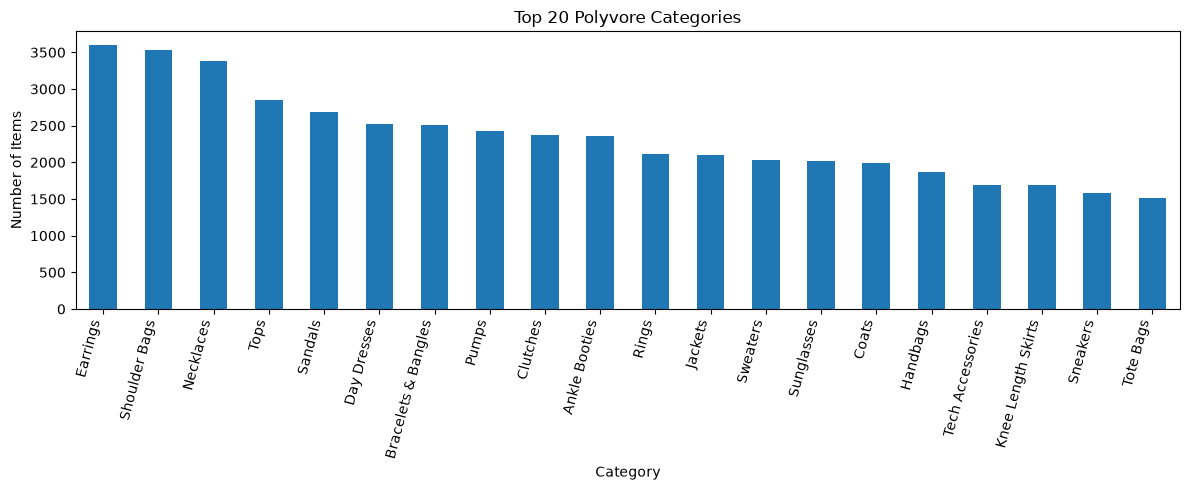

In [8]:
# Cell 8: Dataset statistics

num_items = len(items_df)
num_outfits = items_df["outfit_ID"].nunique()
num_categories = items_df["category"].nunique()

outfit_sizes = (
    items_df
    .groupby("outfit_ID")
    .size()
    .rename("outfit_size")
    .reset_index()
)

category_counts = (
    items_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="item_count")
)

print("Dataset statistics")
print("------------------")
print("Number of items:", num_items)
print("Number of outfits:", num_outfits)
print("Number of unique categories:", num_categories)
print("Average outfit size:", round(outfit_sizes["outfit_size"].mean(), 3))
print("Median outfit size:", outfit_sizes["outfit_size"].median())
print("Minimum outfit size:", outfit_sizes["outfit_size"].min())
print("Maximum outfit size:", outfit_sizes["outfit_size"].max())

print("\nOutfit size distribution:")
display(outfit_sizes["outfit_size"].describe().to_frame("outfit_size_stats"))

print("\nTop 20 categories:")
display(category_counts.head(20))

plt.figure(figsize=(10, 5))
category_counts.head(20).plot(
    x="category",
    y="item_count",
    kind="bar",
    legend=False,
    figsize=(12, 5)
)
plt.title("Top 20 Polyvore Categories")
plt.xlabel("Category")
plt.ylabel("Number of Items")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

Displaying sample outfit: 100002074


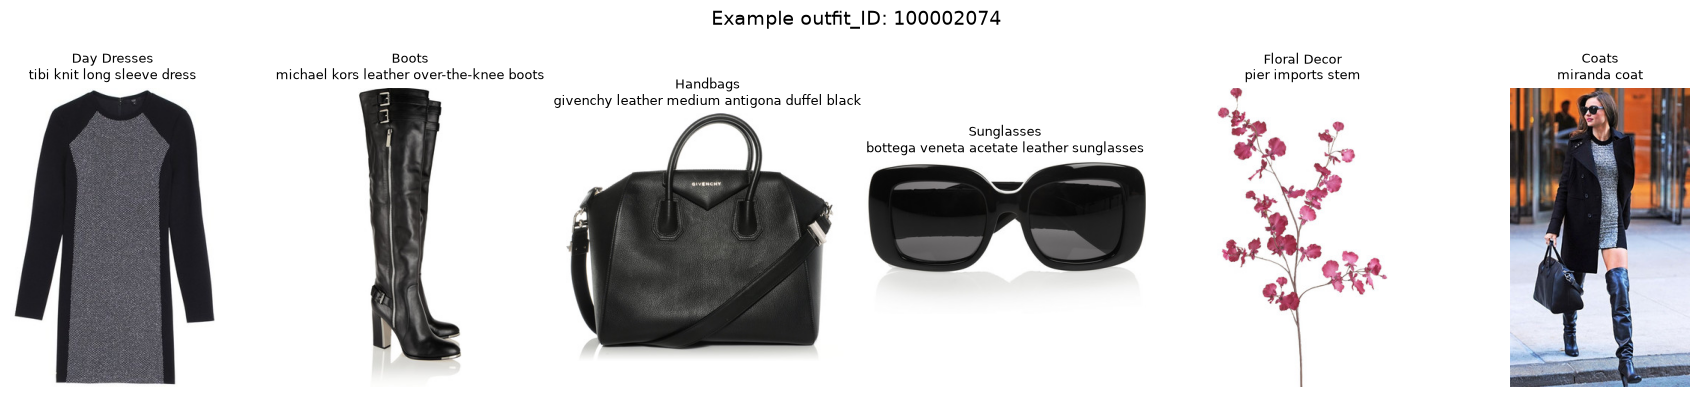

,item_ID,outfit_ID,item_position,category,text
0,100002074_1,100002074,1,Day Dresses,tibi knit long sleeve dress
1,100002074_2,100002074,2,Boots,michael kors leather over-the-knee boots
2,100002074_3,100002074,3,Handbags,givenchy leather medium antigona duffel black
3,100002074_4,100002074,4,Sunglasses,bottega veneta acetate leather sunglasses
4,100002074_5,100002074,5,Floral Decor,pier imports stem
5,100002074_7,100002074,7,Coats,miranda coat


In [9]:
# Cell 9: Display one real outfit with item images

def display_outfit(outfit_id, max_items=8):
    """
    Display all items from one outfit using the original Hugging Face dataset images.
    """
    outfit_rows = (
        items_df[items_df["outfit_ID"] == str(outfit_id)]
        .sort_values("item_position")
        .head(max_items)
    )
    
    if outfit_rows.empty:
        print(f"No outfit found for outfit_ID={outfit_id}")
        return
    
    n_items = len(outfit_rows)
    fig, axes = plt.subplots(1, n_items, figsize=(3 * n_items, 4))
    
    if n_items == 1:
        axes = [axes]
    
    for axis, (_, row) in zip(axes, outfit_rows.iterrows()):
        dataset_index = row.name
        
        # Use the original Hugging Face dataset object so image decoding stays reliable
        image = main_split[int(dataset_index)]["image"]
        
        axis.imshow(image)
        axis.axis("off")
        axis.set_title(
            f"{row['category']}\n{row['text'][:45]}",
            fontsize=9
        )
    
    plt.suptitle(f"Example outfit_ID: {outfit_id}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    display(outfit_rows[["item_ID", "outfit_ID", "item_position", "category", "text"]])


# Pick the first outfit from the dataset for a deterministic example
sample_outfit_id = items_df.loc[0, "outfit_ID"]

print("Displaying sample outfit:", sample_outfit_id)
display_outfit(sample_outfit_id)

In [10]:
# Cell 10: Inspect all fine-grained categories

all_categories = sorted(items_df["category"].dropna().unique())

print("Number of unique fine-grained categories:", len(all_categories))
print("\nAll categories:")
for index, category in enumerate(all_categories, start=1):
    print(f"{index:03d}. {category}")

category_counts_full = (
    items_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="item_count")
)

print("\nTop 50 fine-grained categories:")
display(category_counts_full.head(50))

Number of unique fine-grained categories: 377

All categories:
001. Accent Chairs
002. Accent Tables
003. Accessories
004. Activewear
005. Activewear Jackets
006. Activewear Pants
007. Activewear Shorts
008. Activewear Skirts
009. Activewear Tank Tops
010. Activewear Tops
011. Ankle Booties
012. Aprons
013. Armoires
014. Athletic Shoes
015. Baby
016. Baby Bedding
017. Backpacks
018. Bags
019. Bags & Cases
020. Bakeware
021. Bar Cabinets
022. Bar Tools
023. Barstools
024. Bath
025. Bath & Body
026. Bath Accessories
027. Bath Rugs & Mats
028. Bath Towels
029. Beach Towels
030. Beauty Accessories
031. Beauty Products
032. Bed Accessories
033. Bed Pillows
034. Bedding
035. Beds
036. Bedspreads
037. Belts
038. Benches
039. Bikini Bottoms
040. Bikini Tops
041. Bikinis
042. Blankets
043. Blazers
044. Blouses
045. Blow Dryers & Irons
046. Blush
047. Body Art
048. Body Cleansers
049. Body Moisturizers
050. Bookcases
051. Books
052. Bootcut Jeans
053. Boots
054. Bow Ties
055. Boyfriend Jeans
056

,category,item_count
0,Earrings,3606
1,Shoulder Bags,3525
2,Necklaces,3379
3,Tops,2851
4,Sandals,2689
5,Day Dresses,2525
6,Bracelets & Bangles,2505
7,Pumps,2422
8,Clutches,2377
9,Ankle Booties,2355


In [11]:
# Cell 11: Define broad category mapping rules

BROAD_CATEGORY_RULES = {
    "tops": [
        "top", "tops", "shirt", "shirts", "blouse", "blouses",
        "tee", "t-shirt", "tank", "camisole", "camisoles",
        "sweater", "sweaters", "sweatshirt", "sweatshirts",
        "cardigan", "cardigans", "hoodie", "hoodies",
        "tunic", "tunics", "polo"
    ],
    "bottoms": [
        "jean", "jeans", "trouser", "trousers", "pants",
        "leggings", "shorts", "skirt", "skirts",
        "culottes", "joggers"
    ],
    "shoes": [
        "shoe", "shoes", "boot", "boots", "sneaker", "sneakers",
        "sandal", "sandals", "pump", "pumps", "heel", "heels",
        "flat", "flats", "loafer", "loafers", "oxford", "oxfords",
        "mule", "mules", "slipper", "slippers", "espadrille", "espadrilles"
    ],
    "outerwear": [
        "coat", "coats", "jacket", "jackets", "blazer", "blazers",
        "parka", "parkas", "poncho", "ponchos", "vest", "vests",
        "cape", "capes", "trench"
    ],
    "accessories": [
        "bag", "bags", "handbag", "handbags", "clutch", "clutches",
        "tote", "totes", "backpack", "backpacks", "satchel", "satchels",
        "earring", "earrings", "necklace", "necklaces",
        "bracelet", "bracelets", "bangle", "bangles",
        "ring", "rings", "watch", "watches",
        "sunglasses", "eyewear", "glasses",
        "belt", "belts", "scarf", "scarves",
        "hat", "hats", "beanie", "beanies",
        "wallet", "wallets"
    ],
}


def map_to_broad_category(category):
    """
    Map a fine-grained Polyvore category to one broad thesis category.
    Returns 'other' when the category does not match the target groups.
    """
    category_lower = str(category).lower()
    
    for broad_category, keywords in BROAD_CATEGORY_RULES.items():
        for keyword in keywords:
            if keyword in category_lower:
                return broad_category
    
    return "other"


# Preview mapping on all unique categories
category_mapping_preview = pd.DataFrame({
    "category": all_categories
})

category_mapping_preview["broad_category"] = category_mapping_preview["category"].apply(map_to_broad_category)

print("Broad category mapping preview:")
display(category_mapping_preview)

print("\nNumber of fine categories mapped to each broad category:")
display(
    category_mapping_preview["broad_category"]
    .value_counts()
    .rename_axis("broad_category")
    .reset_index(name="num_fine_categories")
)

Broad category mapping preview:


,category,broad_category
0,Accent Chairs,other
1,Accent Tables,other
2,Accessories,other
3,Activewear,other
4,Activewear Jackets,outerwear
...,...,...
372,Watches,accessories
373,Wedding Dresses,other
374,Wide Leg Jeans,bottoms
375,Window Blinds,other



Number of fine categories mapped to each broad category:


,broad_category,num_fine_categories
0,other,255
1,accessories,39
2,bottoms,25
3,shoes,25
4,tops,23
5,outerwear,10


In [12]:
# Cell 12: Apply broad category mapping and create target item table

items_df["broad_category"] = items_df["category"].apply(map_to_broad_category)

broad_category_counts = (
    items_df["broad_category"]
    .value_counts()
    .rename_axis("broad_category")
    .reset_index(name="item_count")
)

print("Item distribution after broad category mapping:")
display(broad_category_counts)

target_broad_categories = [
    "tops",
    "bottoms",
    "shoes",
    "outerwear",
    "accessories",
]

target_items_df = (
    items_df[items_df["broad_category"].isin(target_broad_categories)]
    .copy()
    .reset_index(drop=False)
    .rename(columns={"index": "original_dataset_index"})
)

print("Original item count:", len(items_df))
print("Target item count:", len(target_items_df))
print("Removed/other item count:", len(items_df) - len(target_items_df))
print("Target item percentage:", round(len(target_items_df) / len(items_df) * 100, 2), "%")

print("\nTarget broad category distribution:")
target_broad_counts = (
    target_items_df["broad_category"]
    .value_counts()
    .rename_axis("broad_category")
    .reset_index(name="item_count")
)

display(target_broad_counts)

print("\nExamples from each broad category:")
for broad_category in target_broad_categories:
    print(f"\n--- {broad_category.upper()} ---")
    display(
        target_items_df[target_items_df["broad_category"] == broad_category]
        [["item_ID", "outfit_ID", "category", "broad_category", "text"]]
        .head(5)
    )

Item distribution after broad category mapping:


,broad_category,item_count
0,accessories,29566
1,other,26572
2,shoes,12635
3,tops,10915
4,bottoms,9247
5,outerwear,5161


Original item count: 94096
Target item count: 67524
Removed/other item count: 26572
Target item percentage: 71.76 %

Target broad category distribution:


,broad_category,item_count
0,accessories,29566
1,shoes,12635
2,tops,10915
3,bottoms,9247
4,outerwear,5161



Examples from each broad category:

--- TOPS ---


...

,item_ID,outfit_ID,category,broad_category,text
0,100002074_2,100002074,Boots,shoes,michael kors leather over-the-knee boots
11,100050716_2,100050716,Sandals,shoes,beige crystal sandals
13,100060207_2,100060207,Pumps,shoes,givenchy striped print pumps yellow grey black
25,100089693_2,100089693,Pumps,shoes,peep-toe black platform high heels
30,100095342_4,100095342,Ankle Booties,shoes,acne short fur lined leather boots



--- OUTERWEAR ---


,item_ID,outfit_ID,category,broad_category,text
3,100002074_7,100002074,Coats,outerwear,miranda coat
4,100010727_1,100010727,Blazers,outerwear,three pocket blazer
28,100095342_2,100095342,Vests,outerwear,fake fur waistcoat
39,100111991_2,100111991,Coats,outerwear,paul joe long fit peacoat
61,100173896_2,100173896,Coats,outerwear,fashion heather coat



--- ACCESSORIES ---


,item_ID,outfit_ID,category,broad_category,text
1,100002074_3,100002074,Handbags,accessories,givenchy leather medium antigona duffel black
2,100002074_4,100002074,Sunglasses,accessories,bottega veneta acetate leather sunglasses
6,100010727_4,100010727,Watches,accessories,guess black silver-tone chronograph watch
7,100010727_5,100010727,Sunglasses,accessories,ray-ban original wayfarer sunglasses
9,100029003_2,100029003,Handbags,accessories,phillip lim red leather satchel


In [13]:
# Cell 13: Add query-only dress category

def map_to_query_category(category):
    """
    Map fine-grained categories for query items.
    This includes the five recommendation groups plus 'dresses' as a valid input/query category.
    """
    category_lower = str(category).lower()
    
    dress_keywords = [
        "dress", "dresses", "gown", "gowns"
    ]
    
    for keyword in dress_keywords:
        if keyword in category_lower:
            return "dresses"
    
    return map_to_broad_category(category)


items_df["query_category"] = items_df["category"].apply(map_to_query_category)

query_category_counts = (
    items_df["query_category"]
    .value_counts()
    .rename_axis("query_category")
    .reset_index(name="item_count")
)

print("Query category distribution:")
display(query_category_counts)

query_allowed_categories = [
    "tops",
    "bottoms",
    "shoes",
    "outerwear",
    "accessories",
    "dresses",
]

query_items_df = (
    items_df[items_df["query_category"].isin(query_allowed_categories)]
    .copy()
    .reset_index(drop=False)
    .rename(columns={"index": "original_dataset_index"})
)

print("Original item count:", len(items_df))
print("Valid query item count:", len(query_items_df))
print("Valid query item percentage:", round(len(query_items_df) / len(items_df) * 100, 2), "%")

print("\nDress examples now available as query items:")
display(
    query_items_df[query_items_df["query_category"] == "dresses"]
    [["item_ID", "outfit_ID", "category", "query_category", "text"]]
    .head(10)
)

Query category distribution:


,query_category,item_count
0,accessories,29566
1,other,22276
2,shoes,12601
3,tops,10871
4,bottoms,9217
5,outerwear,5161
6,dresses,4404


Original item count: 94096
Valid query item count: 71820
Valid query item percentage: 76.33 %

Dress examples now available as query items:


,item_ID,outfit_ID,category,query_category,text
0,100002074_1,100002074,Day Dresses,dresses,tibi knit long sleeve dress
10,100029003_1,100029003,Day Dresses,dresses,rochas dress
15,100060207_1,100060207,Day Dresses,dresses,atelier pleat shift tunic
28,100079699_1,100079699,Day Dresses,dresses,topshop strap back slip dress
29,100089693_1,100089693,Day Dresses,dresses,stripe skinny bodycon mini dress
44,100111991_1,100111991,Day Dresses,dresses,phase eight coral cable swing dress
107,100285829_2,100285829,Dressers,dresses,chest please us
131,100443358_1,100443358,Day Dresses,dresses,marni short boxy fur dress
163,100631293_1,100631293,Cocktail Dresses,dresses,topshop wrap mesh skater dress
168,100658683_1,100658683,Cocktail Dresses,dresses,club l cut mesh peplum dress


In [14]:
# Cell 14: Save processed metadata tables

processed_items_path = PROCESSED_DATA_DIR / "items_clean.parquet"
target_items_path = PROCESSED_DATA_DIR / "target_items.parquet"
query_items_path = PROCESSED_DATA_DIR / "query_items.parquet"
category_mapping_path = PROCESSED_DATA_DIR / "category_mapping_preview.csv"

# Do not save the image column into parquet metadata tables.
# Images remain accessible through the Hugging Face dataset using original_dataset_index.
items_metadata_to_save = items_df.drop(columns=["image"], errors="ignore")
target_metadata_to_save = target_items_df.drop(columns=["image"], errors="ignore")
query_metadata_to_save = query_items_df.drop(columns=["image"], errors="ignore")

items_metadata_to_save.to_parquet(processed_items_path, index=False)
target_metadata_to_save.to_parquet(target_items_path, index=False)
query_metadata_to_save.to_parquet(query_items_path, index=False)
category_mapping_preview.to_csv(category_mapping_path, index=False)

print("Saved processed files:")
print("-", processed_items_path.relative_to(PROJECT_ROOT))
print("-", target_items_path.relative_to(PROJECT_ROOT))
print("-", query_items_path.relative_to(PROJECT_ROOT))
print("-", category_mapping_path.relative_to(PROJECT_ROOT))

print("\nSaved table shapes:")
print("items_clean:", items_metadata_to_save.shape)
print("target_items:", target_metadata_to_save.shape)
print("query_items:", query_metadata_to_save.shape)
print("category_mapping_preview:", category_mapping_preview.shape)

Saved processed files:
- data\processed\items_clean.parquet
- data\processed\target_items.parquet
- data\processed\query_items.parquet
- data\processed\category_mapping_preview.csv

Saved table shapes:
items_clean: (94096, 8)
target_items: (67524, 8)
query_items: (71820, 9)
category_mapping_preview: (377, 2)


In [15]:
# Cell 15: Check outfit coverage after category filtering

target_outfit_counts = (
    target_items_df
    .groupby("outfit_ID")
    .size()
    .rename("num_target_items")
    .reset_index()
)

query_outfit_counts = (
    query_items_df
    .groupby("outfit_ID")
    .size()
    .rename("num_query_items")
    .reset_index()
)

outfit_coverage_df = (
    outfit_sizes
    .merge(target_outfit_counts, on="outfit_ID", how="left")
    .merge(query_outfit_counts, on="outfit_ID", how="left")
)

outfit_coverage_df["num_target_items"] = outfit_coverage_df["num_target_items"].fillna(0).astype(int)
outfit_coverage_df["num_query_items"] = outfit_coverage_df["num_query_items"].fillna(0).astype(int)

usable_outfits_df = outfit_coverage_df[
    (outfit_coverage_df["num_query_items"] >= 1)
    & (outfit_coverage_df["num_target_items"] >= 2)
].copy()

print("Total outfits:", len(outfit_coverage_df))
print("Outfits with at least 1 valid query item and at least 2 target recommendation items:", len(usable_outfits_df))
print("Usable outfit percentage:", round(len(usable_outfits_df) / len(outfit_coverage_df) * 100, 2), "%")

print("\nCoverage statistics:")
display(
    outfit_coverage_df[
        ["outfit_size", "num_query_items", "num_target_items"]
    ].describe()
)

print("\nExample usable outfits:")
display(usable_outfits_df.head(10))

Total outfits: 21587
Outfits with at least 1 valid query item and at least 2 target recommendation items: 17660
Usable outfit percentage: 81.81 %

Coverage statistics:


,outfit_size,num_query_items,num_target_items
count,21587.000000,21587.000000,21587.000000
mean,4.358920,3.327002,3.127994
std,1.739006,1.723292,1.737597
min,1.000000,0.000000,0.000000
25%,3.000000,2.000000,2.000000
50%,4.000000,3.000000,3.000000
75%,6.000000,4.000000,4.000000
max,8.000000,8.000000,8.000000



Example usable outfits:


,outfit_ID,outfit_size,num_target_items,num_query_items
0,100002074,6,4,5
1,100010727,7,5,5
2,100029003,3,2,3
3,100050716,4,2,2
5,100060207,6,5,6
6,100077218,7,7,7
8,100089693,3,2,3
9,100095342,6,6,6
10,100099673,8,6,6
11,100111991,8,6,7


In [16]:
# Cell 16: Analyze broad category composition inside outfits
# RUN AFTER CELLS 1-15 / RERUN ONLY IF CATEGORY MAPPING CHANGES

outfit_broad_composition = (
    target_items_df
    .groupby("outfit_ID")["broad_category"]
    .agg(
        num_target_items="count",
        num_unique_broad_categories="nunique",
        broad_categories=lambda values: sorted(values.unique())
    )
    .reset_index()
)

print("Outfit broad-category composition shape:", outfit_broad_composition.shape)

print("\nBroad-category diversity per outfit:")
display(
    outfit_broad_composition["num_unique_broad_categories"]
    .describe()
    .to_frame("num_unique_broad_categories")
)

print("\nDistribution of number of broad categories per outfit:")
broad_diversity_counts = (
    outfit_broad_composition["num_unique_broad_categories"]
    .value_counts()
    .sort_index()
    .rename_axis("num_unique_broad_categories")
    .reset_index(name="num_outfits")
)
display(broad_diversity_counts)

print("\nExample outfits with many broad categories:")
display(
    outfit_broad_composition
    .sort_values(["num_unique_broad_categories", "num_target_items"], ascending=False)
    .head(10)
)

Outfit broad-category composition shape: (20148, 4)

Broad-category diversity per outfit:


,num_unique_broad_categories
count,20148.000000
mean,2.617977
std,1.129536
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,5.000000



Distribution of number of broad categories per outfit:


,num_unique_broad_categories,num_outfits
0,1,3658
1,2,6195
2,3,5483
3,4,3810
4,5,1002



Example outfits with many broad categories:


,outfit_ID,num_target_items,num_unique_broad_categories,broad_categories
32,100445477,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
161,102665177,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
218,103867145,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
298,105081429,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
338,105881838,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
365,106100743,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
391,106345656,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
429,106813596,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
777,111059798,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
832,111632032,8,5,"[accessories, bottoms, outerwear, shoes, tops]"


Broad category co-occurrence matrix:


,tops,bottoms,shoes,outerwear,accessories
tops,10101,6172,6354,2561,7888
bottoms,6172,9040,5716,2445,7044
shoes,6354,5716,12346,3316,9993
outerwear,2561,2445,3316,5066,4035
accessories,7888,7044,9993,4035,16194


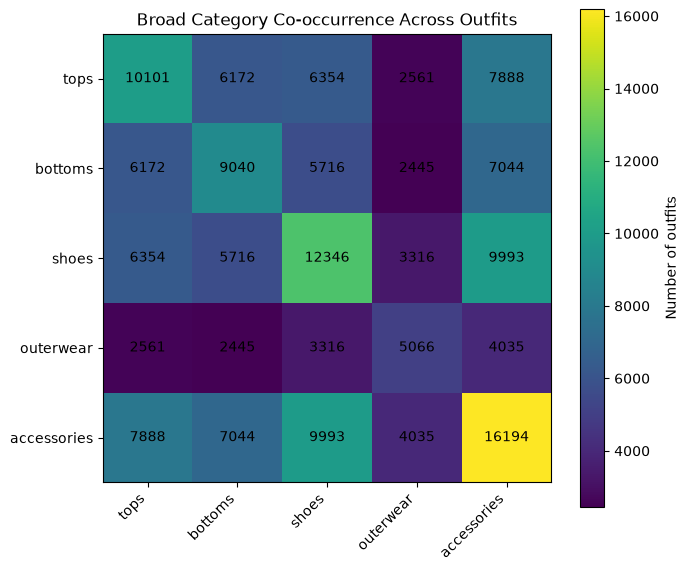

In [17]:
# Cell 17: Category co-occurrence matrix
# RUN AFTER CELLS 1-16 / RERUN ONLY IF CATEGORY MAPPING CHANGES

broad_categories_order = [
    "tops",
    "bottoms",
    "shoes",
    "outerwear",
    "accessories",
]

cooccurrence_matrix = pd.DataFrame(
    0,
    index=broad_categories_order,
    columns=broad_categories_order,
    dtype=int
)

for _, row in outfit_broad_composition.iterrows():
    categories_in_outfit = set(row["broad_categories"])
    
    for category_a in broad_categories_order:
        for category_b in broad_categories_order:
            if category_a in categories_in_outfit and category_b in categories_in_outfit:
                cooccurrence_matrix.loc[category_a, category_b] += 1

print("Broad category co-occurrence matrix:")
display(cooccurrence_matrix)

plt.figure(figsize=(7, 6))
plt.imshow(cooccurrence_matrix.values)
plt.xticks(range(len(broad_categories_order)), broad_categories_order, rotation=45, ha="right")
plt.yticks(range(len(broad_categories_order)), broad_categories_order)
plt.title("Broad Category Co-occurrence Across Outfits")
plt.colorbar(label="Number of outfits")

for row_index in range(len(broad_categories_order)):
    for col_index in range(len(broad_categories_order)):
        plt.text(
            col_index,
            row_index,
            cooccurrence_matrix.values[row_index, col_index],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Testing display helper with outfit_ID: 100002074


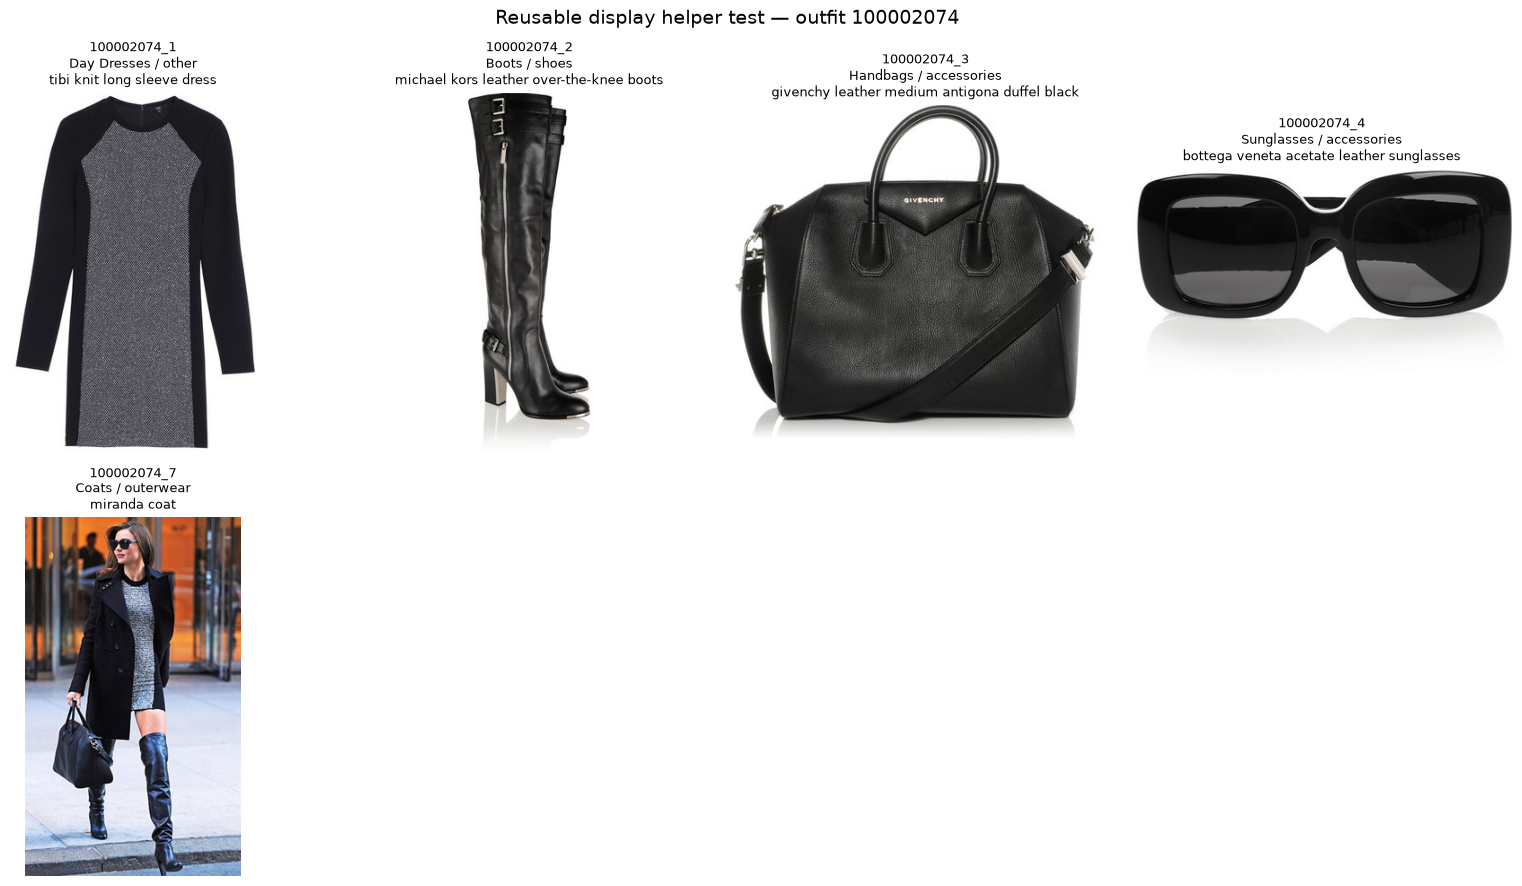

,item_ID,outfit_ID,item_position,category,broad_category,query_category,text
0,100002074_1,100002074,1,Day Dresses,other,dresses,tibi knit long sleeve dress
1,100002074_2,100002074,2,Boots,shoes,shoes,michael kors leather over-the-knee boots
2,100002074_3,100002074,3,Handbags,accessories,accessories,givenchy leather medium antigona duffel black
3,100002074_4,100002074,4,Sunglasses,accessories,accessories,bottega veneta acetate leather sunglasses
4,100002074_7,100002074,7,Coats,outerwear,outerwear,miranda coat


In [18]:
# Cell 18: Reusable visual display helper for items
# RUN EVERY SESSION AFTER DATASET AND METADATA ARE LOADED

def display_items_grid(items_table, title="Items", max_items=8, image_index_column="original_dataset_index"):
    """
    Display a grid of item images using original Hugging Face dataset indexes.
    Expected columns include item_ID, category, text, and original_dataset_index.
    """
    if items_table.empty:
        print("No items to display.")
        return
    
    display_table = items_table.head(max_items).copy()
    n_items = len(display_table)
    
    cols = min(n_items, 4)
    rows = math.ceil(n_items / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[axis] for axis in axes])
    
    axes_flat = axes.flatten()
    
    for axis in axes_flat:
        axis.axis("off")
    
    for axis, (_, row) in zip(axes_flat, display_table.iterrows()):
        dataset_index = int(row[image_index_column])
        image = main_split[dataset_index]["image"]
        
        axis.imshow(image)
        axis.axis("off")
        
        label = (
            f"{row['item_ID']}\n"
            f"{row['category']}"
        )
        
        if "broad_category" in row:
            label += f" / {row['broad_category']}"
        elif "query_category" in row:
            label += f" / {row['query_category']}"
        
        label += f"\n{str(row['text'])[:45]}"
        
        axis.set_title(label, fontsize=9)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    table_columns = [
        column for column in [
            "item_ID",
            "outfit_ID",
            "item_position",
            "category",
            "broad_category",
            "query_category",
            "text",
        ]
        if column in display_table.columns
    ]
    
    display(display_table[table_columns])


# Test the helper on one usable outfit
example_usable_outfit_id = usable_outfits_df.iloc[0]["outfit_ID"]

example_items = (
    query_items_df[query_items_df["outfit_ID"] == example_usable_outfit_id]
    .sort_values("item_position")
)

print("Testing display helper with outfit_ID:", example_usable_outfit_id)
display_items_grid(
    example_items,
    title=f"Reusable display helper test — outfit {example_usable_outfit_id}",
    max_items=8
)

In [19]:
# Cell 19: Load text embedding model
# RUN EVERY SESSION BEFORE EMBEDDING OR RETRIEVAL CELLS

from sentence_transformers import SentenceTransformer

TEXT_EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading text embedding model:", TEXT_EMBEDDING_MODEL_NAME)
print("Device:", device)

text_embedding_model = SentenceTransformer(
    TEXT_EMBEDDING_MODEL_NAME,
    device=device
)

sample_texts = target_items_df["item_text"].head(5).tolist()

sample_embeddings = text_embedding_model.encode(
    sample_texts,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=False
)

print("Model loaded successfully.")
print("Sample texts:", sample_texts)
print("Sample embedding shape:", sample_embeddings.shape)
print("Embedding dtype:", sample_embeddings.dtype)

Loading text embedding model: sentence-transformers/all-MiniLM-L6-v2
Device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully.
Sample texts: ['Boots | michael kors leather over-the-knee boots', 'Handbags | givenchy leather medium antigona duffel black', 'Sunglasses | bottega veneta acetate leather sunglasses', 'Coats | miranda coat', 'Blazers | three pocket blazer']
Sample embedding shape: (5, 384)
Embedding dtype: float32


In [20]:
# Cell 20: Compute or load target item text embeddings
# RUN EVERY SESSION; FIRST RUN COMPUTES, LATER RUNS LOAD CACHE

target_embeddings_path = EMBEDDINGS_DIR / "target_text_embeddings_all_minilm_l6_v2.npy"
target_metadata_path = PROCESSED_DATA_DIR / "target_items_for_embeddings.parquet"

# Save matching metadata so embedding row order is always reproducible.
target_items_for_embeddings = target_items_df.reset_index(drop=True).copy()
target_items_for_embeddings.to_parquet(target_metadata_path, index=False)

if target_embeddings_path.exists():
    print("Loading cached target embeddings from:")
    print(target_embeddings_path.relative_to(PROJECT_ROOT))
    
    target_text_embeddings = np.load(target_embeddings_path)
    
else:
    print("Computing target item text embeddings.")
    print("Number of target items:", len(target_items_for_embeddings))
    
    target_texts = target_items_for_embeddings["item_text"].fillna("").tolist()
    
    target_text_embeddings = text_embedding_model.encode(
        target_texts,
        batch_size=256,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True
    )
    
    np.save(target_embeddings_path, target_text_embeddings)
    
    print("Saved target embeddings to:")
    print(target_embeddings_path.relative_to(PROJECT_ROOT))

print("Target embedding matrix shape:", target_text_embeddings.shape)
print("Target metadata shape:", target_items_for_embeddings.shape)

assert len(target_items_for_embeddings) == target_text_embeddings.shape[0], (
    "Metadata rows and embedding rows do not match."
)

print("Target embeddings are ready.")

Computing target item text embeddings.
Number of target items: 67524


Batches:   0%|          | 0/264 [00:00<?, ?it/s]

Saved target embeddings to:
outputs\embeddings\target_text_embeddings_all_minilm_l6_v2.npy
Target embedding matrix shape: (67524, 384)
Target metadata shape: (67524, 9)
Target embeddings are ready.


In [21]:
# Cell 21: Build category-aware FAISS indexes
# RUN EVERY SESSION AFTER TARGET EMBEDDINGS ARE AVAILABLE

import faiss

embedding_dim = target_text_embeddings.shape[1]

category_indexes = {}
category_row_lookup = {}

for broad_category in target_broad_categories:
    category_rows = target_items_for_embeddings.index[
        target_items_for_embeddings["broad_category"] == broad_category
    ].to_numpy()
    
    category_embeddings = target_text_embeddings[category_rows].astype("float32")
    
    # Embeddings are already normalized, so inner product = cosine similarity.
    index = faiss.IndexFlatIP(embedding_dim)
    index.add(category_embeddings)
    
    category_indexes[broad_category] = index
    category_row_lookup[broad_category] = category_rows
    
    print(
        f"{broad_category:12s} | "
        f"items: {len(category_rows):6d} | "
        f"index vectors: {index.ntotal:6d}"
    )

print("\nBuilt category-aware FAISS indexes.")
print("Available target categories:", list(category_indexes.keys()))

tops         | items:  10915 | index vectors:  10915
bottoms      | items:   9247 | index vectors:   9247
shoes        | items:  12635 | index vectors:  12635
outerwear    | items:   5161 | index vectors:   5161
accessories  | items:  29566 | index vectors:  29566

Built category-aware FAISS indexes.
Available target categories: ['tops', 'bottoms', 'shoes', 'outerwear', 'accessories']
